In [2]:
from nba_api.stats.endpoints import playergamelogs

logs = playergamelogs.PlayerGameLogs(
    season_nullable="2024-25",
    season_type_nullable="Regular Season"
)

df = logs.get_data_frames()[0]

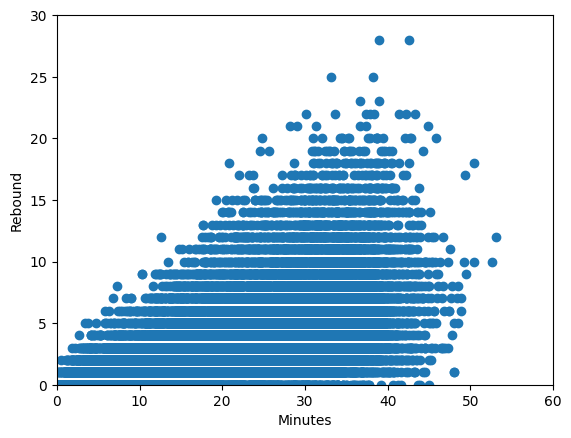

0.5505330480772551
0.3030866370252332


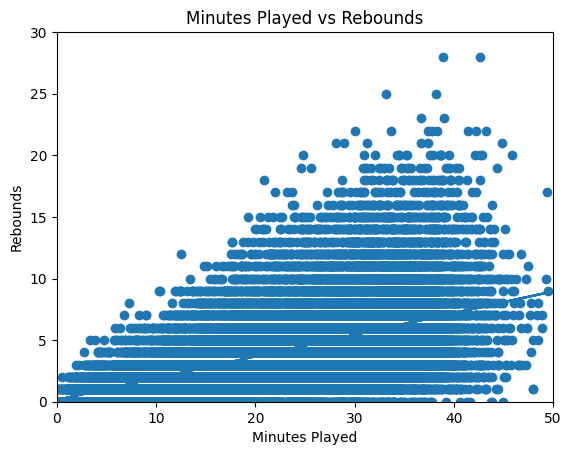

In [ ]:
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt


min_reb = df[["MIN", "REB"]]
min_reb.head()
min_reb.shape
min_reb.isnull().sum()
plt.scatter(min_reb["MIN"], min_reb["REB"])
plt.xlim(0, 60)
plt.ylim(0, 30)
plt.xlabel("Minutes")
plt.ylabel("Rebound")
plt.show()
print(min_reb["MIN"].corr(min_reb["REB"]))

X= min_reb[["MIN"]]
y = min_reb["REB"]
model = LinearRegression()
model.fit(X, y)
r2 = model.score(X, y)
print(r2)
predictions = model.predict(X)
plt.scatter(min_reb["MIN"], min_reb["REB"])

plt.plot(min_reb["MIN"], predictions)

plt.xlim(0, 50)
plt.ylim(0, 30)

plt.xlabel("Minutes Played")
plt.ylabel("Rebounds")
plt.title("Minutes Played vs Rebounds")

plt.show()

"""Feature: MIN (Minutes Played)

Correlation with REB: ~0.55
R²: ~0.30

Observation:
Minutes played has a moderate positive relationship with rebounds.
Players who play more minutes generally have more rebounds, but there is
still a lot of variation between players.

Pre-game usable? NO — actual game minutes are not known beforehand.

Potential transformation:
Use recent minutes, such as MIN_LAST_5, or an expected-minutes estimate.

Decision:
KEEP / INVESTIGATE FURTHER"""